In [102]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from collections import defaultdict
random.seed(123)
np.random.seed(123)

# Algorithms

In [103]:
def partition(X, M):
  # returns list of M np arrays of length subset_size. Assumes iid. Shuffle before passing in
  subsets = []
  subset_size = math.floor(X.size/M)
  for i in range(int(math.ceil(M))):
    start = i*subset_size
    end = start + subset_size
    if end < len(X):
      subsets.append(X[start:end])
    else:
      return subsets
  return subsets

## PDPODME

In [104]:
def getBins(R, r):
  bins = []
  increment = -1*R - 2*r
  while increment <= R + 2*r:
    bins.append(increment)
    increment += 2*r
  return bins

def getHistogram(X, bins):
  histogram = []
  X = np.sort(X)
  loc = 0
  while X[loc] < bins[0]:
    loc+=1
  if loc>len(X):
    return histogram

  for increment in bins[1:]:
    count = 0
    while X[loc] < increment:
      loc+=1
      count+=1
      if loc>=len(X):
        histogram.append(count)
        while len(histogram) < len(bins)-1:
          histogram.append(0)
        return histogram
    histogram.append(count)
  return histogram

# Algorithm 1
def PDPRE(X, eps, alpha, R, k):
  r = 10/(math.pow(alpha, 1/(k-1)))
  # print("r:", r) # fine
  bins = getBins(R, r)
  # print("Bins:")
  # print(bins)

  histogram = getHistogram(X, bins)
  # print("Histogram:")
  # print(histogram)

  for i in range(len(histogram)):
    histogram[i] += np.random.laplace(0, 2/eps)
  # print("Noisy Histogram:")
  # print(histogram)
  top_bin = np.argmax(np.array(histogram))
  a = bins[top_bin]
  b = bins[top_bin+1]
  # print("a=", a)
  # print("b=", b)
  left = a-2*r
  right = b+2*r
  # print("I=[", left, ",", right, "]")
  return left, right

  # Algorithm 2
def PDPODME(X, eps, alpha, R, nu, beta):
  # beta is prob of failure
  n = len(X)/2
  k = nu-1 # Num bounded moments
  m = 200*math.log(2/beta)
  Z = X[:math.ceil(n)]
  W = X[math.ceil(n):]
  mu_hats = []
  # print(m)
  # print(int(math.floor(n/k)))
  for i in range(1, math.ceil(m)):
    Y_i = W[(i-1)*int(math.floor(n/k)):i*int(math.floor(n/k))]
    Z_i = Z[(i-1)*int(math.floor(n/k)):i*int(math.floor(n/k))]
    #print("avg:", Z_i.mean()) # fine. rly close to 5
    if len(Z_i)==0: # Z_i now empty. done
      # print(i) # fine
      break
    left, right = PDPRE(Z_i, eps, alpha, R, k)
    # print(left, right) # fine
    r_i = right-left # always 4r?
    # print("r_i", r_i)
    for j in range(len(Y_i)):
      if Y_i[j] < left:
        Y_i[j] = left
      elif Y_i[j] > right:
        Y_i[j] = right
    # print("nonnoisy q, m*r_i/(eps*n))
    # should this be over len(Y_i)? paper says n.
    mu_hat_i = sum(Y_i)/len(Y_i) + np.random.laplace(m*r_i/(eps*n))
    mu_hats.append(mu_hat_i)
  return np.median(mu_hats)

## Quantiles

In [105]:
def positiveQuantileSearch ( data , b , q , eps_1 , eps_2 ):
  d = defaultdict (int)
  for x in data :
    if x+1<0:
      d[-2500] +=1
    else:
      i = math.log( x+1 , b ) // 1
      d[i] += 1
  t = q * len( data ) + np.random.laplace (0,  1/ eps_1 )
  cur , i = 0 , min(d.keys())
  first_pass = True
  while i < 100000 :
    cur += d[i]
    i += 1
    rand_cur = cur + np.random.laplace (0, 1/ eps_2 )
    if rand_cur > t:
      if first_pass:
        return -1
      break
    first_pass = False
  # print("d:")
  # print(d)
  return b ** i -1

def negativeQuantileSearch ( data , b , q , eps_1 , eps_2 ):
  d = defaultdict (int)
  for x in data :
    if -1*(x-1) < 0:
      d[-2500] +=1
    else:
      i = math.log(-1*(x-1), b ) // 1 # floor
      d[i] += 1
  t = (1-q) * len( data ) + np.random.laplace (0,  1/ eps_1 )
  cur , i = 0 , min(d.keys())
  first_pass = True
  while i < 100000:
    cur += d[i]
    i += 1
    rand_cur = cur + np.random.laplace (0, 1/ eps_2 )
    if rand_cur > t:
      if first_pass:
        return 1
      break
    first_pass = False
  # print("d:")
  # print(d)
  return -1 * (b ** i -1)

def privateQuantile(data, b, q, eps_1, eps_2):
  pos = positiveQuantileSearch(data, b, q, eps_1/2, eps_2/2)
  if pos!=-1:
    return pos
  neg = negativeQuantileSearch(data, b, q, eps_1/2, eps_2/2)
  if neg!=1:
    return neg
  return 0

def privateMedianOfMeans(data, B, eps1, eps2):
  blocks = partition(data, B)
  means = [np.mean(block) for block in blocks]
  # print("means:", means)
  priv_med = privateQuantile(means, 1.001, 0.5, eps1, eps2)
  return priv_med

In [106]:
def privateTrimmedMean(X, eps, delta):
    N = len(X)
    q = 24*math.log(4/delta)/len(X)
    left = privateQuantile(X[:int(N/2)], 1.001, q, eps/5, eps/5)
    right = privateQuantile(X[:int(N/2)], 1.001, 1-q, eps/5, eps/5)
    Y = np.clip(X[int(N/2):], left, right)
    return np.mean(Y) + np.random.laplace(0, (right-left)*2/(N*eps/5))

## PRIME 1D

In [107]:
def dp_range(X, epsilon,delta, R):
    n = X.shape[0]
    d = X.shape[1]
    x_bar = np.zeros(d)
    for i in range(d):
        bins = np.linspace(-R-0.5, R+0.5, 2*int(R))
        hist,  _ = np.histogram(X[:,i], bins=bins)
        hist = hist/n
        for h in range(len(hist)):
            if hist[h]!=0:
                hist[h] += np.random.laplace(0, 2/(n*epsilon/d))
            if hist[h]<2*np.log(d/delta)/(epsilon*n/d)+1/n:
                hist[h] = 0
        x_bar[i] = bins[np.argmax(hist)]+bins[np.argmax(hist)+1]

    return x_bar, 4*np.sqrt(np.log(d*n/0.9))

def PRIME_1D(epsilon, delta, X, alpha, R):
    X = np.asarray(X).flatten()
    n = len(X)

    # 1D range estimation
    x_bar, B = dp_range(X.reshape(-1, 1), 0.01*epsilon, 0.01*delta, R=R)
    x_bar = float(x_bar)  # extract scalar

    # clip to range
    X_clipped = np.clip(X, x_bar - B, x_bar + B)

    # T1/T2 defaults for d=1
    mean = filter_MMW_1d(
        X=X_clipped.reshape(-1, 1),
        alpha=alpha,
        epsilon=0.99*epsilon,
        delta=0.99*delta,
        B=B
    )

    return float(mean)


def filter_MMW_1d(X, alpha, epsilon, delta, B):
    n = len(X)

    mu = np.mean(X) + np.random.normal(0, B*np.sqrt(2*np.log(1.25/delta))/(n*epsilon))

    tau = np.abs(X - mu).flatten()

    k = int(alpha * n)
    k = int(alpha * n)

    k = max(1, int(alpha * n))
    threshold = np.partition(tau, -k)[-k]

    S = np.where(tau <= threshold)[0]

    return np.mean(X[S]) + np.random.normal(0, B*np.sqrt(2*np.log(1.25/delta))/(len(S)*epsilon))


# Experiments

## Hyperparameters

### PDPODME $\alpha, \beta, R$

In [108]:
alphas = [0.025*i for i in range(1, 15)]
betas = [0.025*i for i in range(1, 15)]
eps = 10
k=4
trials = 10
R = 100
n= 25000
errors = np.zeros((len(alphas), len(betas)))
for a in range(len(alphas)):
    for b in range(len(betas)):
        for _ in range(trials):
            X = np.random.standard_t(5, n)
            mu = np.random.choice(range(-50, 50))
            X = X + mu
            errors[a, b] = abs(PDPODME(X, eps, alphas[a], R, k, betas[b])-mu)

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-1437425166.py:4: SyntaxWarning: invalid escape sequence '\h'
  cbar.set_label("$|\hat{\mu} - \mu|$", fontsize=20)   # label font size


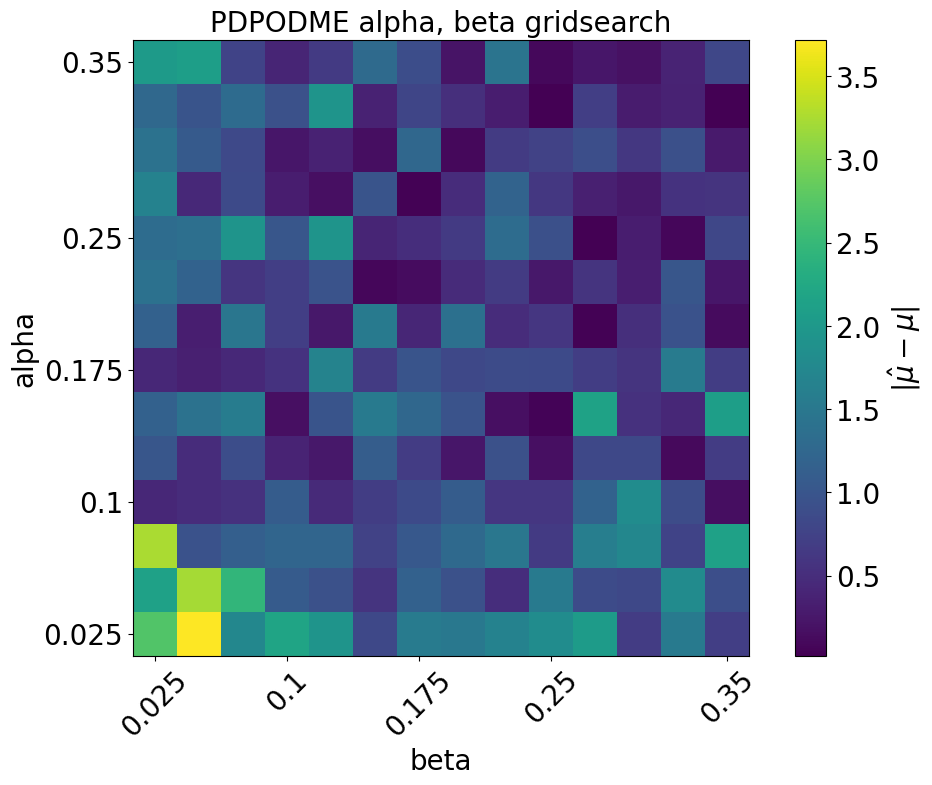

In [109]:
plt.figure(figsize=(12,8))
im = plt.imshow(errors, cmap='viridis', aspect='equal')
cbar = plt.colorbar(im)
cbar.set_label("$|\hat{\mu} - \mu|$", fontsize=20)   # label font size
cbar.ax.tick_params(labelsize=20)
plt.title("PDPODME alpha, beta gridsearch", fontsize=20)
plt.xlabel("beta", fontsize=20)
plt.ylabel("alpha", fontsize=20)
max_ticks = 5
alpha_idx = np.linspace(0, len(alphas) - 1, min(len(alphas), max_ticks), dtype=int)
plt.yticks(alpha_idx, np.round(np.array(alphas)[alpha_idx], 3), fontsize=20)
plt.gca().invert_yaxis()

beta_idx = np.linspace(0, len(betas) - 1, min(len(betas), max_ticks), dtype=int)
plt.xticks(beta_idx, np.round(np.array(betas)[beta_idx], 3), rotation=45, fontsize=20)

plt.show()


In [110]:
n = 25000
trials = 10
eps = 10
Rs = [2*i for i in range(25, 50)]
hist_errors = np.zeros((len(Rs), trials))
alpha, beta = 0.15, 0.1
k = 4
for i in range(len(Rs)):
  for t in range(trials):
    X = np.random.standard_t(5, n)
    mu = np.random.choice(range(-50, 50))
    X = X + mu
    hist_errors[i, t] = abs(PDPODME(X, eps, alpha, Rs[i], k, beta)-mu)

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-2636342669.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)


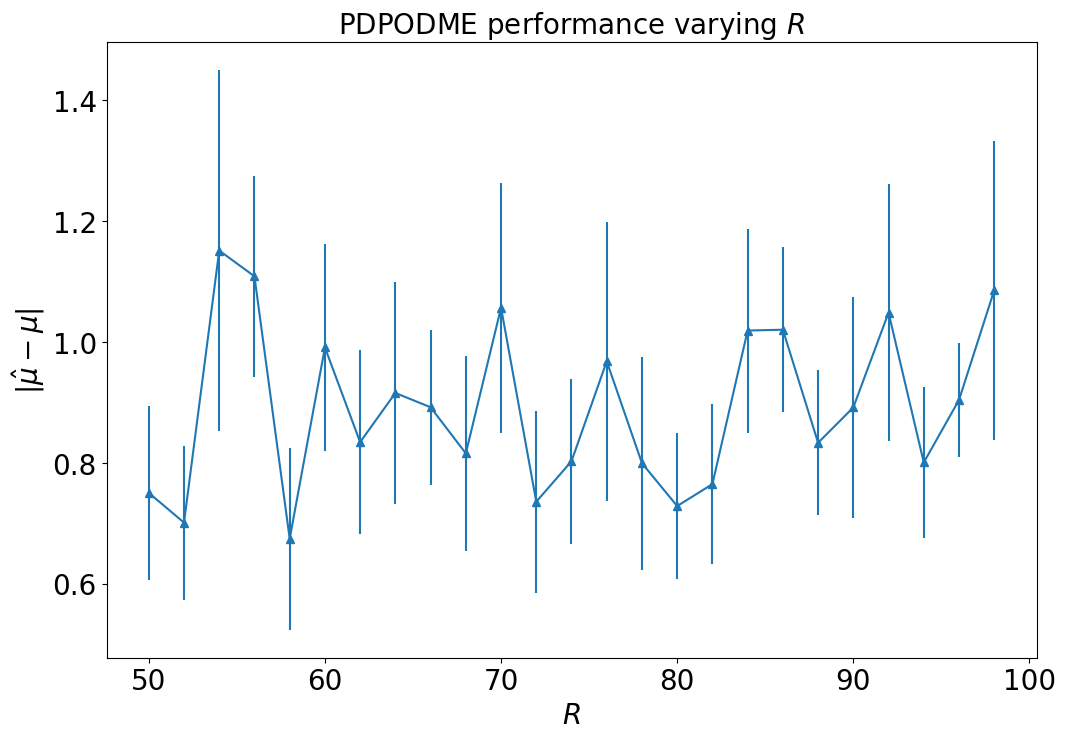

In [111]:
plt.figure(figsize=(12,8))
plt.errorbar(Rs, hist_errors.mean(axis=1), np.std(hist_errors, axis=1)/np.sqrt(trials), marker='^')
plt.xlabel('$R$', fontsize=20)
plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
plt.title("PDPODME performance varying $R$", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

$R=80$

### PrivMoM $\epsilon_1, \epsilon_2$, B

In [112]:
n = 25000
trials = 10
eps = 10
diff = [0.1*i for i in range(5, 98)]
mom_errors = np.zeros((len(diff), trials))
for i in range(len(diff)):
  eps1 = diff[i]
  eps2 = eps-diff[i]
  for t in range(trials):
    X = np.random.standard_t(5, n)
    mu = np.random.choice(range(-50, 50))
    X = X + mu
    mom_errors[i, t] = abs(privateMedianOfMeans(X, n/500, eps1, eps2)-mu)


<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-3326319610.py:8: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon_1$', fontsize=20)
/tmp/ipython-input-3326319610.py:9: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
/tmp/ipython-input-3326319610.py:10: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Performance with varying $\epsilon$ splits", fontsize=20)


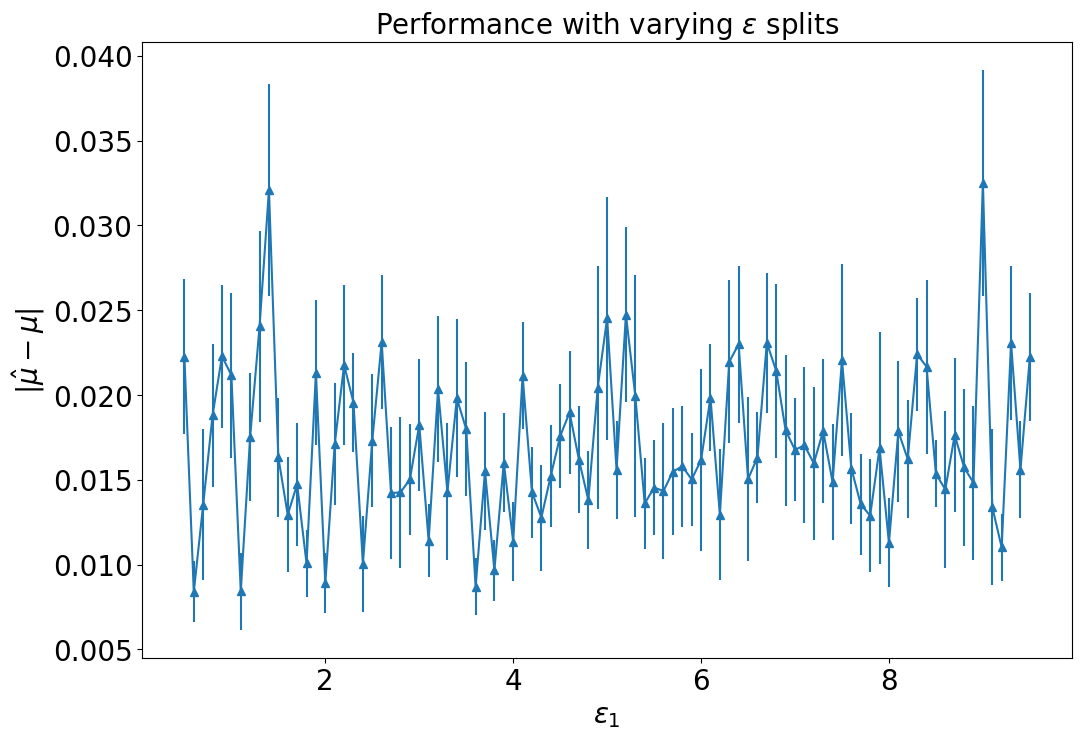

In [113]:
plt.figure(figsize=(12,8))
plt.errorbar(
    diff[:-2],
    mom_errors.mean(axis=1)[:-2],
    np.std(mom_errors, axis=1)[:-2] / np.sqrt(trials),
    marker='^'
)
plt.xlabel('$\epsilon_1$', fontsize=20)
plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
plt.title("Performance with varying $\epsilon$ splits", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

makes no diff. Take $\epsilon_1 = \epsilon_2 = \epsilon/2$

In [114]:
n = 25000
trials = 10
eps = 10
Bs = [i for i in range(50, n) if n%i==0]
mom_errors = np.zeros((len(Bs), trials))
for i in range(len(Bs)):
  # print("B:", Bs[i])
  for t in range(trials):
    X = np.random.standard_t(5, n)
    mu = np.random.choice(range(-50, 50))
    X = X + mu
    mom_errors[i, t] = abs(privateMedianOfMeans(X, Bs[i], eps/2, eps/2)-mu)


<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-2428353821.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)


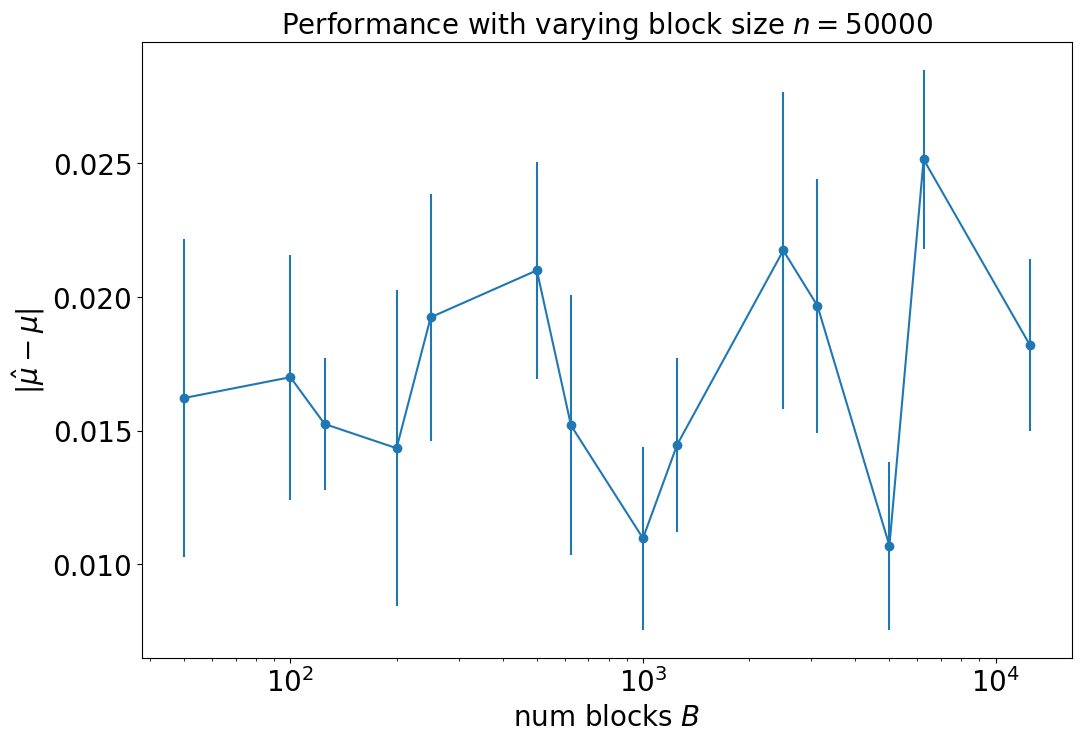

In [115]:
plt.figure(figsize=(12,8))
plt.errorbar(Bs, mom_errors.mean(axis=1), np.std(mom_errors, axis=1)/np.sqrt(trials), marker='o')
plt.xlabel('num blocks $B$', fontsize=20)
plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
plt.title("Performance with varying block size $n=50000$", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xscale('log')
plt.show()

In [116]:
order = np.argsort(mom_errors.mean(axis=1))
Bs_sorted = np.array(Bs)[order]
Bs_sorted

array([ 5000,  1000,   200,  1250,   625,   125,    50,   100, 12500,
         250,  3125,   500,  2500,  6250])

In [117]:
B=200

## Sample Complexity

In [118]:
ns = [i*2000 for i in range(2,50)]
trials = 10
eps = 10
avg_errors = np.zeros((len(ns), trials))
tm_errors = np.zeros((len(ns), trials))
mom_errors = np.zeros((len(ns), trials))
hist_errors = np.zeros((len(ns), trials))
prime_errors = np.zeros((len(ns), trials))
for i in range(len(ns)):
  for t in range(trials):
    X = np.random.standard_t(5, ns[i])
    mu = np.random.choice(range(-50, 50))
    X = X + mu
    # print("actual median:", np.quantile(X, 0.5))
    # print("actual mean:", np.mean(X))
    # print("len X:", len(X))
    avg_errors[i, t] = abs(X.mean()-mu)
    tm_errors[i, t] = abs(privateTrimmedMean(X, eps, 0.1)-mu)
    mom_errors[i, t] = abs(privateMedianOfMeans(X, B, eps/2, eps/2)-mu)
    hist_errors[i, t] = abs(PDPODME(X, eps, alpha, 100, k, beta)-mu)
    prime_errors[i, t] = abs(PRIME_1D(epsilon=eps, delta=0.01, X=X, alpha=0.05, R=100)-mu)

/tmp/ipython-input-2182448301.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_bar = float(x_bar)  # extract scalar


<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-3367938783.py:8: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
/tmp/ipython-input-3367938783.py:9: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Standard t (5 df) $\epsilon=10$", fontsize=20)


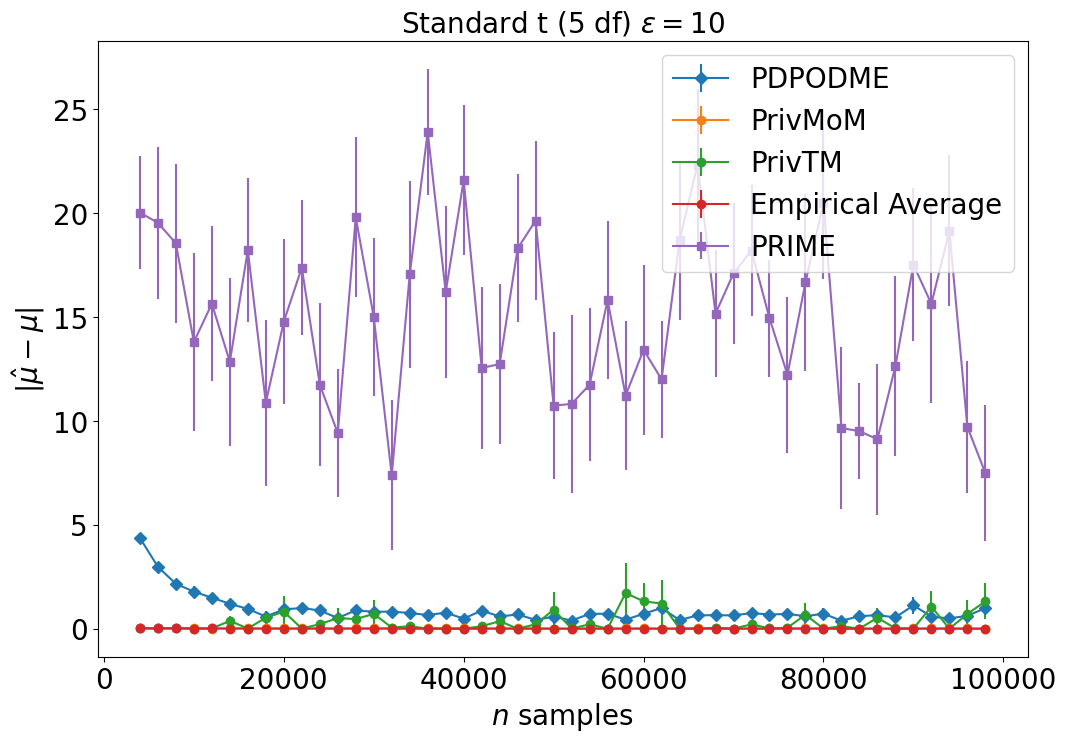

In [119]:
plt.figure(figsize=(12,8))
plt.errorbar(ns, hist_errors.mean(axis=1), np.std(hist_errors, axis=1)/np.sqrt(trials), marker='D', label = 'PDPODME')
plt.errorbar(ns, mom_errors.mean(axis=1), np.std(mom_errors, axis=1)/np.sqrt(trials), marker='o', label = 'PrivMoM')
plt.errorbar(ns, tm_errors.mean(axis=1), np.std(tm_errors, axis=1)/np.sqrt(trials), marker='o', label = 'PrivTM')
plt.errorbar(ns, avg_errors.mean(axis=1), np.std(avg_errors, axis=1)/np.sqrt(trials), marker='o', label = 'Empirical Average')
plt.errorbar(ns, prime_errors.mean(axis=1), np.std(prime_errors, axis=1)/np.sqrt(trials), marker='s', label = 'PRIME')
plt.xlabel('$n$ samples', fontsize=20)
plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
plt.title("Standard t (5 df) $\epsilon=10$", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2294332043.py:7: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
/tmp/ipython-input-2294332043.py:8: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Standard t (5 df) $\epsilon=10$", fontsize=20)


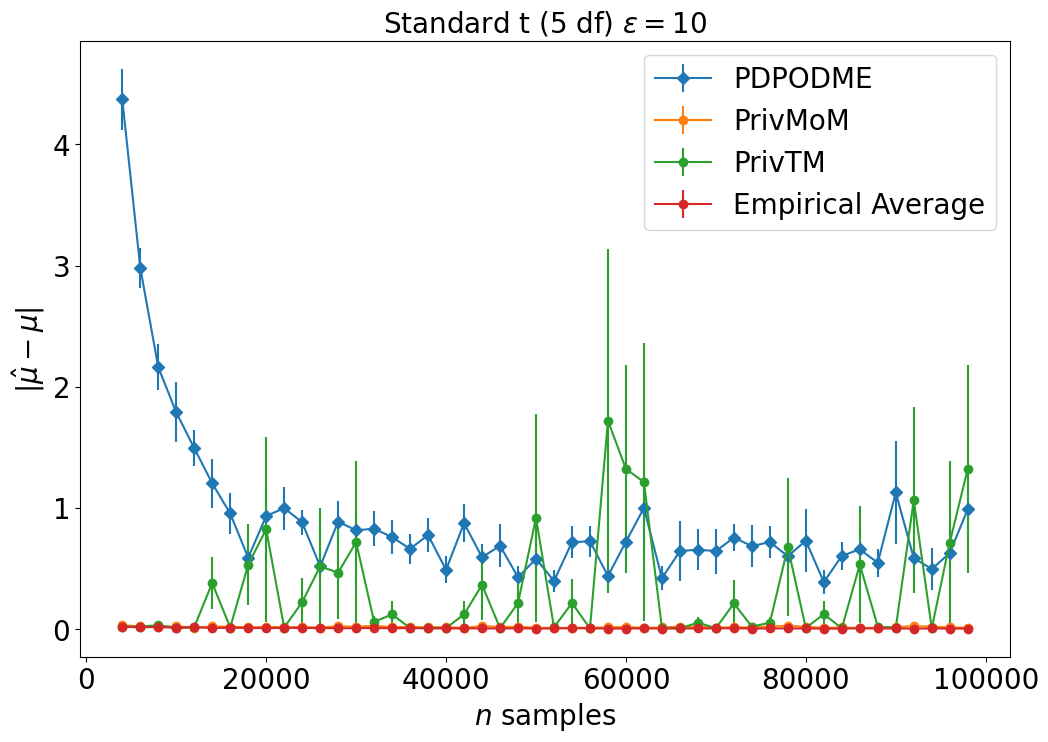

In [120]:
plt.figure(figsize=(12,8))
plt.errorbar(ns, hist_errors.mean(axis=1), np.std(hist_errors, axis=1)/np.sqrt(trials), marker='D', label = 'PDPODME')
plt.errorbar(ns, mom_errors.mean(axis=1), np.std(mom_errors, axis=1)/np.sqrt(trials), marker='o', label = 'PrivMoM')
plt.errorbar(ns, tm_errors.mean(axis=1), np.std(tm_errors, axis=1)/np.sqrt(trials), marker='o', label = 'PrivTM')
plt.errorbar(ns, avg_errors.mean(axis=1), np.std(avg_errors, axis=1)/np.sqrt(trials), marker='o', label = 'Empirical Average')
plt.xlabel('$n$ samples', fontsize=20)
plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
plt.title("Standard t (5 df) $\epsilon=10$", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.show()

In [121]:
def MedianOfMeans(X, B):
  blocks = partition(X, B)
  return np.median([np.mean(block) for block in blocks])

def TrimmedMean(X, rho):
  N = len(X)
  q = 24*math.log(4/rho)/len(X)
  left = np.quantile(X[:int(N/2)], q)
  right = np.quantile(X[:int(N/2)], 1-q)
  Y = np.clip(X[int(N/2):], left, right)
  return np.mean(Y)

In [122]:
ns = [i*2000 for i in range(2,50)]
trials = 100
eps = 2
tm_errors = np.zeros((len(ns), trials))
avg_errors = np.zeros((len(ns), trials))
mom_errors = np.zeros((len(ns), trials))
hist_errors = np.zeros((len(ns), trials))
mom2_errors = np.zeros((len(ns), trials))
for i in range(len(ns)):
  for t in range(trials):
    X = np.random.standard_t(5, ns[i])
    mu = np.random.choice(range(-50, 50))
    X = X + mu
    pmom = privateMedianOfMeans(X, B, eps/2, eps/2)
    avg_errors[i, t] = abs(X.mean()-mu)
    mom_errors[i, t] = abs(pmom-mu)
    mom2_errors[i, t] = abs(MedianOfMeans(X, B)-mu)
    tm_errors[i, t] = abs(privateTrimmedMean(X, eps, 0.1)-mu)
    # hist_errors[i, t] = abs(PDPODME(X, eps, 0.1, 80, 4, 0.1)-mu)

In [123]:
# plot 1/sqrt(n) error curve
minimax_rate = [math.sqrt(5/3)/(math.sqrt(n)*2) for n in ns]
priv_minimax_rate = [math.sqrt(5/3)/(math.sqrt(n)) + math.sqrt(5/3)/(n*eps) for n in ns]

<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-174642124.py:10: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
/tmp/ipython-input-174642124.py:11: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Student-t (5 df) $\epsilon=2$", fontsize=20)


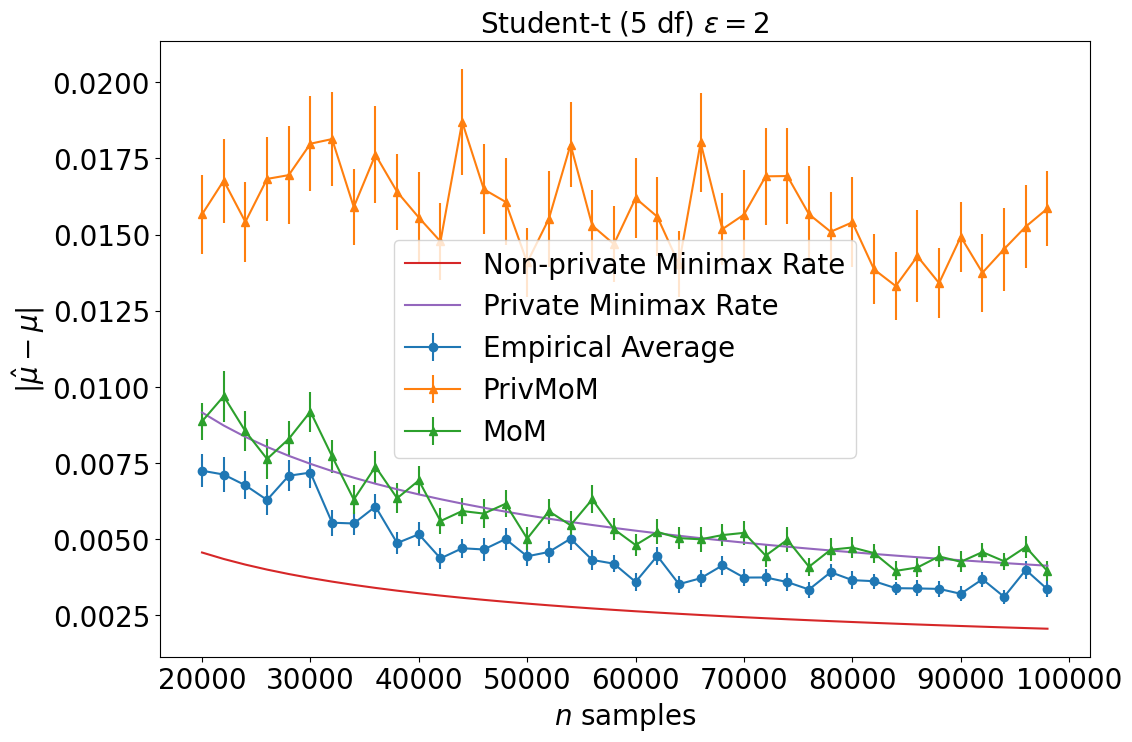

In [124]:
plt.figure(figsize=(12,8))
plt.errorbar(ns[-40:], avg_errors[-40:].mean(axis=1), np.std(avg_errors[-40:], axis=1)/np.sqrt(trials), marker='o', label = 'Empirical Average')
plt.errorbar(ns[-40:], mom_errors[-40:].mean(axis=1), np.std(mom_errors[-40:], axis=1)/np.sqrt(trials), marker='^', label = 'PrivMoM')
plt.errorbar(ns[-40:], mom2_errors[-40:].mean(axis=1), np.std(mom2_errors[-40:], axis=1)/np.sqrt(trials), marker='^', label = 'MoM')
# plt.errorbar(ns[-40:], tm_errors[-40:].mean(axis=1), np.std(tm_errors[-40:], axis=1)/np.sqrt(trials), marker='^', label = 'PrivTM')
# plt.errorbar(ns[-80:], hist_errors[-80:].mean(axis=1), np.std(hist_errors[-80:], axis=1)/np.sqrt(trials), marker='s', label = 'PDPODME')
plt.plot(ns[-40:], minimax_rate[-40:], label="Non-private Minimax Rate")
plt.plot(ns[-40:], priv_minimax_rate[-40:], label="Private Minimax Rate")
plt.xlabel('$n$ samples', fontsize=20)
plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
plt.title("Student-t (5 df) $\epsilon=2$", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.show()

## Dependence on $\epsilon$

In [125]:
n = 50000
trials = 10
eps = [0.2*i for i in range(1, 70)]
mom_errors = np.zeros((len(eps), trials))
hist_errors = np.zeros((len(eps), trials))
tm_errors = np.zeros((len(eps), trials))
alpha, beta = 0.1, 0.1
R = 100
k = 4
for i in range(len(eps)):
  for t in range(trials):
    X = np.random.standard_t(5, n)
    mu = np.random.choice(range(-50, 50))
    X = X + mu
    pmom = privateMedianOfMeans(X, B, eps[i]/2, eps[i]/2)
    hist_errors[i, t] = abs(PDPODME(X, eps[i], alpha, R, k, beta)-mu)
    mom_errors[i, t] = abs(pmom-mu)
    tm_errors[i,t] = abs(privateTrimmedMean(X, eps[i], 0.1))

<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-959898218.py:5: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$', fontsize=20)
/tmp/ipython-input-959898218.py:6: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
/tmp/ipython-input-959898218.py:7: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Performance with varying $\epsilon$", fontsize=20)


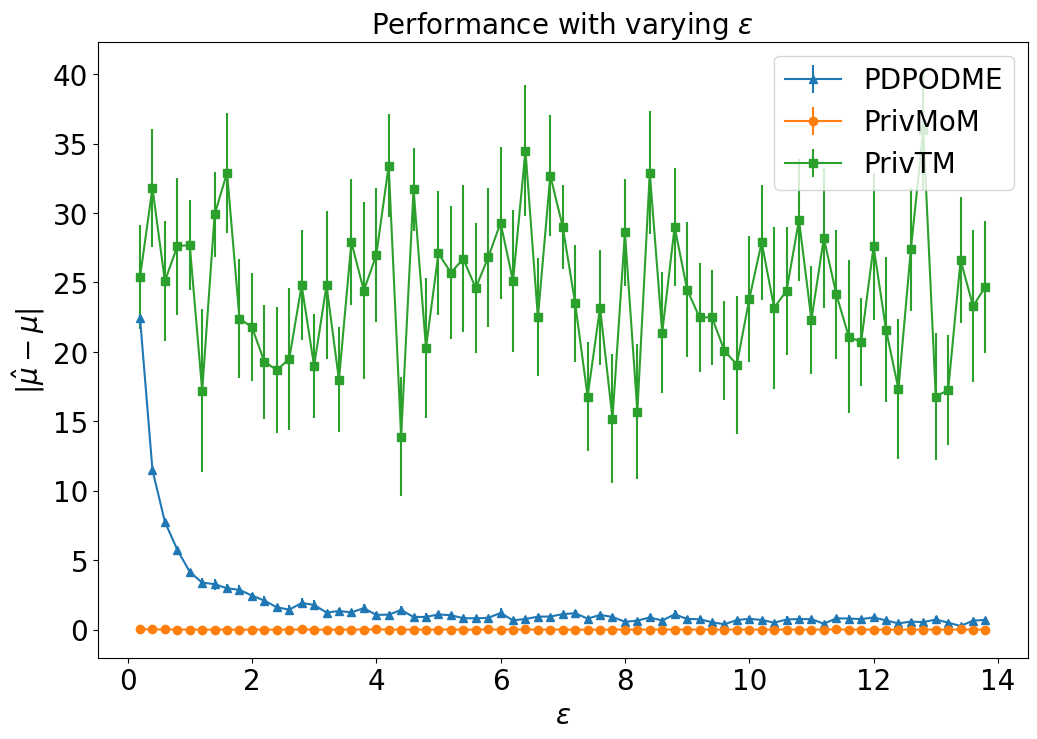

In [126]:
plt.figure(figsize=(12,8))
plt.errorbar(eps, hist_errors.mean(axis=1), np.std(hist_errors, axis=1)/np.sqrt(trials), marker='^', label="PDPODME")
plt.errorbar(eps, mom_errors.mean(axis=1), np.std(mom_errors, axis=1)/np.sqrt(trials), marker='o', label='PrivMoM')
plt.errorbar(eps, tm_errors.mean(axis=1), np.std(tm_errors, axis=1)/np.sqrt(trials), marker='s', label="PrivTM")
plt.xlabel('$\epsilon$', fontsize=20)
plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
plt.title("Performance with varying $\epsilon$", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2227609953.py:3: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$', fontsize=20)
/tmp/ipython-input-2227609953.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
/tmp/ipython-input-2227609953.py:5: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Performance with varying $\epsilon$", fontsize=20)


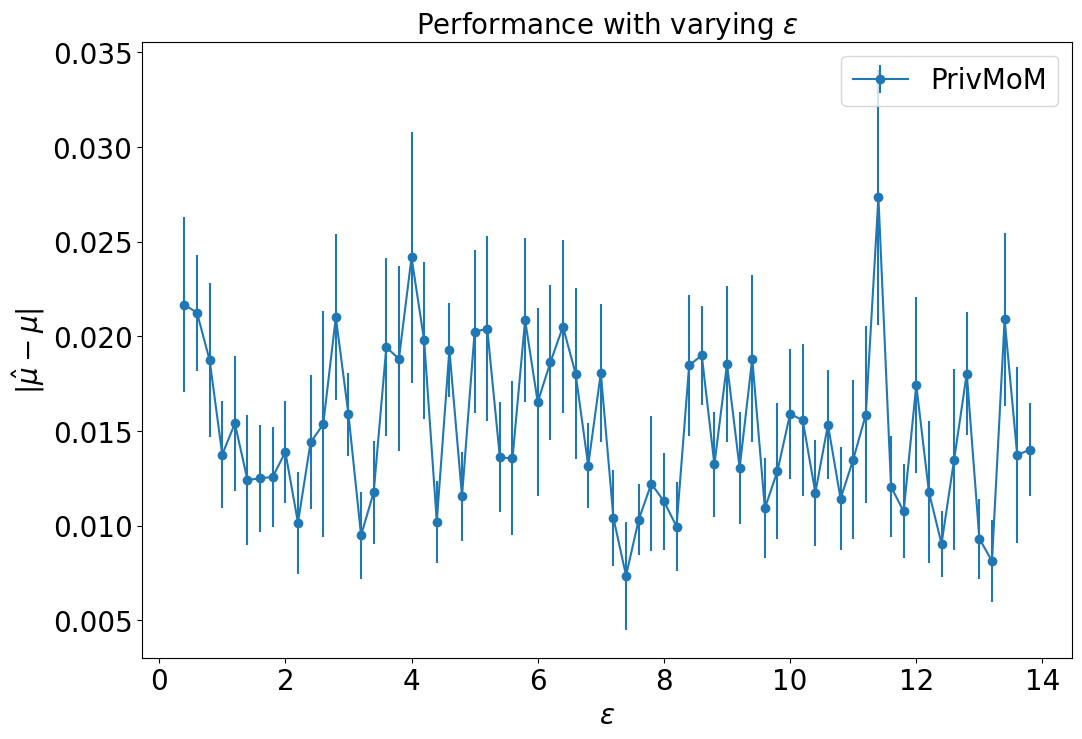

In [127]:
plt.figure(figsize=(12,8))
plt.errorbar(eps[1:], mom_errors[1:].mean(axis=1), np.std(mom_errors, axis=1)[1:]/np.sqrt(trials), marker='o', label='PrivMoM')
plt.xlabel('$\epsilon$', fontsize=20)
plt.ylabel('$|\hat{\mu}-\mu|$', fontsize=20)
plt.title("Performance with varying $\epsilon$", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.show()

## Privacy Audit

In [180]:
random.seed(123)
np.random.seed(123)

trials = 10000
n = 1000
eps = 2

H0_mus = []
H1_mus = []

H0_mus_nonpriv = []
H1_mus_nonpriv = []

# X = np.random.standard_t(5, size=n)
# X = X + 5

# X = np.random.normal(loc=-3, scale=4, size=n)

# ones = np.ones(int(n/2))
# zeros = np.zeros(int(n/2))
# X = np.concat([ones, zeros])

# X = np.random.choice(range(0, 10), size=n)

X = np.random.rayleigh(4, size=n)

#H0
for _ in range(trials):
    mu_hat = privateMedianOfMeans(X, B, eps/2, eps/2)
    mu_hat2 = MedianOfMeans(X, B)
    # mu_hat = PDPODME(X, eps, 0.1, 20, 4, 0.1)
    H0_mus.append(mu_hat)
    H0_mus_nonpriv.append(mu_hat2)

# H1
X[0] = 20 # canary value
for _ in range(trials):
    mu_hat = privateMedianOfMeans(X, B, eps/2, eps/2)
    mu_hat2 = MedianOfMeans(X, B)
    # mu_hat = PDPODME(X, eps, 0.1, 20, 4, 0.1)
    H1_mus.append(mu_hat)
    H1_mus_nonpriv.append(mu_hat2)


In [181]:
thresholds = np.linspace(4.8, 5.1, 80)
alphas = []
betas = []
H0_mus = np.array(H0_mus)
H1_mus = np.array(H1_mus)
for threshold in thresholds:
    beta = len(H0_mus[H0_mus > threshold])/trials
    betas.append(beta)
    alpha = len(H1_mus[H1_mus <= threshold])/trials
    alphas.append(alpha)

In [182]:
x1 = np.linspace(0, 1, 50)
y1 = np.array([1-math.pow(math.e, eps) * x_i for x_i in x1])
y1 = y1[y1>=0]
x1 = x1[:len(y1)]

y2 = np.linspace(0, 1, 50)
x2 = np.array([1-math.pow(math.e, eps) * y_i for y_i in y2])
x2 = x2[x2>=0]
y2 = y2[:len(x2)]

x3 = np.linspace(0, 1, 50)
y3 = x3[::-1]

<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-1992200548.py:10: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_xlabel("$\hat{\mu}$")
/tmp/ipython-input-1992200548.py:15: SyntaxWarning: invalid escape sequence '\e'
  axes[2].plot(x1,y1, label="$\epsilon=2$ bound", color='r')


Text(0.5, 1.0, 'Membership inference error')

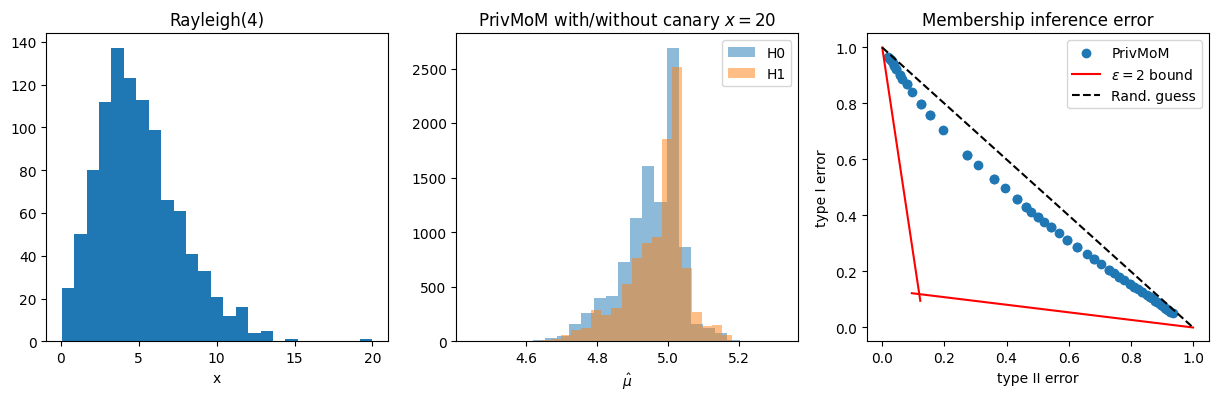

In [183]:
fig, axes = plt.subplots(1,3, figsize=(15, 4))
axes[0].hist(X, 25)
axes[0].set_title("Rayleigh(4)")
axes[0].set_xlabel("x")
# axes[0].set_ylabel("freq")
axes[1].hist(H0_mus, 25, label="H0", alpha=0.5)
axes[1].hist(H1_mus, 25, label="H1", alpha=0.5)
axes[1].set_title("PrivMoM with/without canary $x=20$")
axes[1].legend()
axes[1].set_xlabel("$\hat{\mu}$")
# axes[1].set_ylabel("freq")
axes[2].scatter(betas, alphas, label="PrivMoM")
axes[2].set_xlabel("type II error")
axes[2].set_ylabel("type I error")
axes[2].plot(x1,y1, label="$\epsilon=2$ bound", color='r')
axes[2].plot(x2,y2, color='r')
axes[2].plot(x3,y3, label="Rand. guess", color='black', linestyle = "--")
axes[2].legend()
axes[2].set_title("Membership inference error")

# Numerical Instability

In [192]:
np.random.seed(123)
trials=2000
X = np.random.standard_t(5, size=n)
X = X + 1000
eps=2
mus = []
for _ in range(trials):
  mus.append(privateMedianOfMeans(X, B, eps/2, eps/2))

<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-1789336671.py:8: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_xlabel("$\hat{\mu}$")


Text(0.5, 0, '$\\hat{\\mu}$')

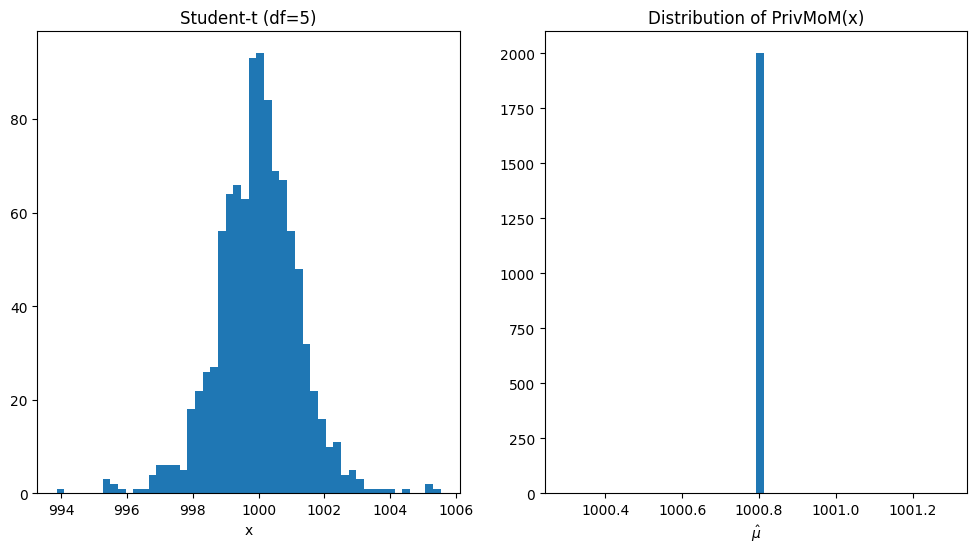

In [193]:
fig, axes = plt.subplots(1,2, figsize=(12, 6))
axes[0].hist(X, 50)
axes[0].set_title("Student-t (df=5)")
axes[0].set_xlabel("x")
# axes[0].set_ylabel("freq")
axes[1].hist(mus, 50)
axes[1].set_title("Distribution of PrivMoM(x)")
axes[1].set_xlabel("$\hat{\mu}$")

In [194]:
X = np.random.standard_t(5, size=n)
X = X + 250
eps=2
mus = []
for _ in range(trials):
  mus.append(privateMedianOfMeans(X, B, eps/2, eps/2))

<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-1789336671.py:8: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_xlabel("$\hat{\mu}$")


Text(0.5, 0, '$\\hat{\\mu}$')

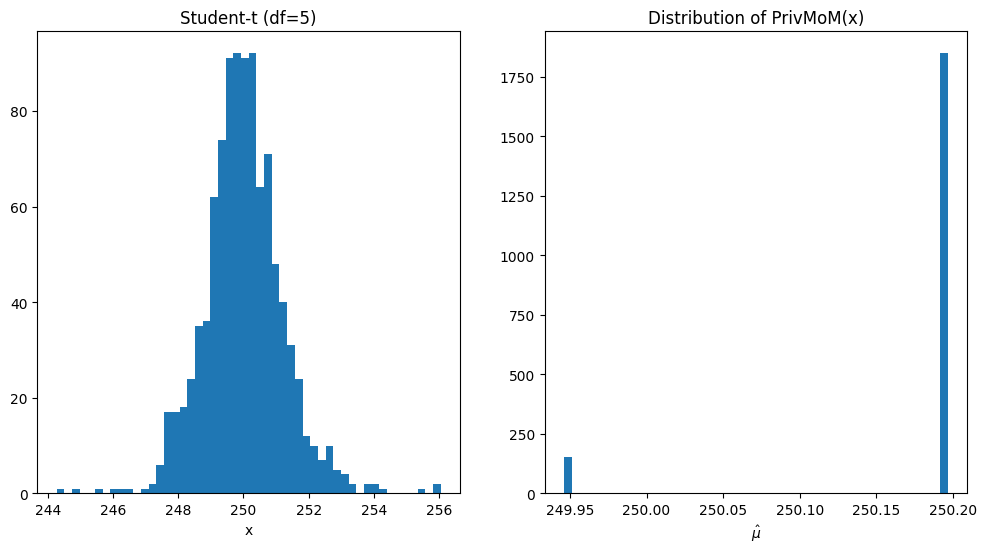

In [195]:
fig, axes = plt.subplots(1,2, figsize=(12, 6))
axes[0].hist(X, 50)
axes[0].set_title("Student-t (df=5)")
axes[0].set_xlabel("x")
# axes[0].set_ylabel("freq")
axes[1].hist(mus, 50)
axes[1].set_title("Distribution of PrivMoM(x)")
axes[1].set_xlabel("$\hat{\mu}$")